# EDA — `datasets_claudeopus_sample2` vs `datasets_llama2`

Both directories hold the same kind of artifact: synthetic HUMAN/ASSISTANT conversations generated to
express one of four behavioural attributes — **gullibility**, **rationality**, **seriousness**,
**certainty_seeking** — at a discrete level (`low` / `medium` (or `neutral` for certainty_seeking) / `high`),
for training/probing the attribute-detection pipeline in this repo.

| | `datasets_claudeopus_sample2` | `datasets_llama2` |
|---|---|---|
| Generator | `claude-opus-5` | Llama 2 |
| Sidecar metadata | per-conversation `.json` (topic, seed, model, leak checks) | none — `.txt` only |
| `run.log` | present — a resumable batch job, target **1200** conversations (100/level × 3 levels × 4 attributes) | none |
| On disk now | 761 conversations, 63% of target (run is **incomplete**, resumed mid-way) | 602 conversations |

**Scope of this notebook:** it characterizes the *generated text itself* — volume, structure, length,
vocabulary, topic coverage, and generation-pipeline data-quality issues (duplicates, malformed turns,
label leakage). It does **not** evaluate whether the low/medium/high manipulation actually produces the
intended behavioural signal — that's the job of the downstream probe/steering pipeline
(`src/probe_common`, `nb/causality_tests/`) and is out of scope here. The `claudeopus_sample2` run is
also explicitly unfinished (`run.log` shows `Resuming: 48 conversation(s) already on disk`), so counts
below are a snapshot of a job in progress, not a final dataset size.

In [1]:
import hashlib
import json
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 200)
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["axes.grid"] = False

DATASETS = {
    "claudeopus_sample2": Path("../datasets_claudeopus_sample2"),
    "llama2": Path("../datasets_llama2"),
}
ATTRS = ["gullibility", "rationality", "seriousness", "certainty_seeking"]

# fixed palette: one colour per dataset, reused in every chart below
PALETTE = {"claudeopus_sample2": "#3B6E8F", "llama2": "#C97B4A"}
LEVEL_ORDER = ["low", "medium", "neutral", "high"]
LEVEL_COLORS = {"low": "#8FB8D9", "medium": "#3B6E8F", "neutral": "#3B6E8F", "high": "#1B3A4B"}

## 1 · Load & parse

Each `.txt` file is `HUMAN: ...` / `ASSISTANT: ...` turns, role markers anchored at the start of a line. `certainty_seeking` uses `low/neutral/high` instead of `low/medium/high` — the filename regex accepts both.

In [2]:
TURN_RE = re.compile(r"^(HUMAN|ASSISTANT): ", re.MULTILINE)
FNAME_RE = re.compile(r"conversation_(\d+)_(.+)_(low|medium|neutral|high)\.txt$")


def parse_turns(text: str):
    matches = list(TURN_RE.finditer(text))
    turns = []
    for i, m in enumerate(matches):
        start = m.end()
        end = matches[i + 1].start() if i + 1 < len(matches) else len(text)
        turns.append((m.group(1), text[start:end].strip()))
    return turns


conv_rows = []
turn_rows = []
bad_filenames = []

for ds_name, ds_path in DATASETS.items():
    for attr in ATTRS:
        d = ds_path / attr
        if not d.exists():
            continue
        for f in sorted(d.glob("*.txt")):
            m = FNAME_RE.match(f.name)
            if not m:
                bad_filenames.append(str(f))
                continue
            idx, _attr_from_name, level = m.groups()
            text = f.read_text()
            turns = parse_turns(text)
            if not turns:
                bad_filenames.append(str(f))
                continue
            roles = [r for r, _ in turns]
            alt_ok = roles[0] == "HUMAN" and all(roles[i] != roles[i - 1] for i in range(1, len(roles)))
            human_words = sum(len(c.split()) for r, c in turns if r == "HUMAN")
            asst_words = sum(len(c.split()) for r, c in turns if r == "ASSISTANT")

            meta = {}
            jf = f.with_suffix(".json")
            if jf.exists():
                meta = json.loads(jf.read_text())

            conv_rows.append(dict(
                dataset=ds_name, attribute=attr, level=level, idx=int(idx),
                path=str(f),
                text_sha=hashlib.sha256(text.encode()).hexdigest(),
                num_turns=len(turns),
                n_human=roles.count("HUMAN"), n_assistant=roles.count("ASSISTANT"),
                alt_ok=alt_ok,
                human_words=human_words, asst_words=asst_words,
                total_words=human_words + asst_words,
                stage_dirs=len(re.findall(r"<[^<>]{1,40}>", text)),
                topic=meta.get("topic"), model=meta.get("model"),
                seed=meta.get("seed"),
                leak_stems=len(meta.get("leak_stems_found") or []),
                has_json=bool(meta),
            ))
            for t_no, (role, content) in enumerate(turns):
                turn_rows.append(dict(
                    dataset=ds_name, attribute=attr, level=level, idx=int(idx),
                    turn_no=t_no, role=role, words=len(content.split()), chars=len(content),
                ))

df = pd.DataFrame(conv_rows)
turns_df = pd.DataFrame(turn_rows)
df["level"] = pd.Categorical(df["level"], categories=LEVEL_ORDER, ordered=True)

print(f"conversations parsed: {len(df)}   turns parsed: {len(turns_df)}   unparseable files: {len(bad_filenames)}")
df.groupby("dataset").size()

conversations parsed: 1363   turns parsed: 12214   unparseable files: 0


dataset
claudeopus_sample2    761
llama2                602
dtype: int64

## 2 · Overview — how much data is there, and is it balanced

level                                  low  medium  neutral  high
dataset            attribute                                     
claudeopus_sample2 certainty_seeking  60.0     NaN     63.0  62.0
                   gullibility        64.0    66.0      NaN  63.0
                   rationality        64.0    64.0      NaN  64.0
                   seriousness        63.0    64.0      NaN  64.0
llama2             certainty_seeking  50.0     NaN     50.0  50.0
                   gullibility        52.0    50.0      NaN  50.0
                   rationality        50.0    50.0      NaN  50.0
                   seriousness        50.0    50.0      NaN  50.0

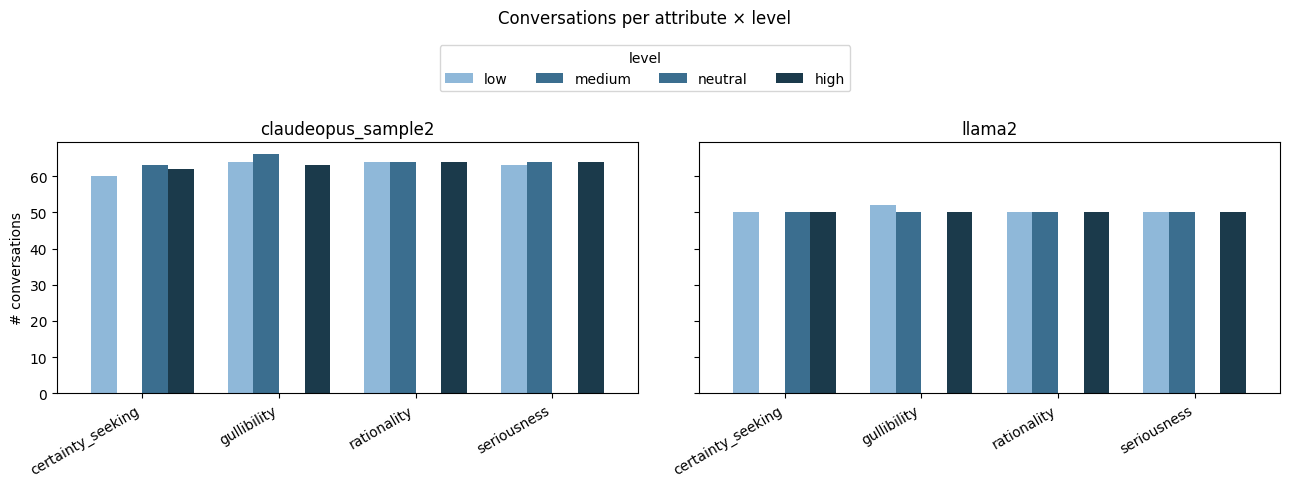

claudeopus_sample2 total: 761 / 1200 target (63% — run.log confirms this batch is still in progress)
llama2 total: 602


In [3]:
counts = df.groupby(["dataset", "attribute", "level"], observed=True).size().unstack("level")
display(counts)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
for ax, (ds_name, sub) in zip(axes, df.groupby("dataset")):
    piv = sub.groupby(["attribute", "level"], observed=True).size().unstack("level")
    piv = piv[[c for c in LEVEL_ORDER if c in piv.columns]]
    piv.plot(kind="bar", ax=ax, color=[LEVEL_COLORS[c] for c in piv.columns], width=0.75, legend=False)
    ax.set_title(ds_name)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    for lbl in ax.get_xticklabels():
        lbl.set_ha("right")
axes[0].set_ylabel("# conversations")
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, title="level", loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.08))
fig.suptitle("Conversations per attribute × level", y=1.15)
plt.tight_layout()
plt.show()

print(f"claudeopus_sample2 total: {len(df[df.dataset=='claudeopus_sample2'])} / 1200 target "
      f"({len(df[df.dataset=='claudeopus_sample2']) / 1200:.0%} — run.log confirms this batch is still in progress)")
print(f"llama2 total: {len(df[df.dataset=='llama2'])}")

`claudeopus_sample2` is close to even across levels within each attribute (the generator batches 2-per-level and stops mid-batch on interruption/resume, so small imbalances are just where the in-progress run happened to be paused). `llama2` is closer to a flat 50/level design.

## 3 · Structural sanity check — role alternation

Turns are expected to strictly alternate `HUMAN, ASSISTANT, HUMAN, ...` starting with `HUMAN`. Violations mean the generator produced two consecutive turns from the same role (a real generation artifact, not a level-manipulation signal).

In [4]:
bad_alt = df[~df.alt_ok]
print(f"role-alternation violations: {len(bad_alt)} / {len(df)} conversations")
display(bad_alt.groupby("dataset").size().rename("violations"))
display(bad_alt[["dataset", "attribute", "level", "idx"]].head(10))

role-alternation violations: 10 / 1363 conversations


dataset
llama2    10
Name: violations, dtype: int64

,dataset,attribute,level,idx
851,llama2,gullibility,high,37
856,llama2,gullibility,medium,38
933,llama2,rationality,medium,15
966,llama2,rationality,medium,25
1008,llama2,rationality,medium,38
1033,llama2,rationality,high,46
1035,llama2,rationality,medium,46
1042,llama2,rationality,high,49
1059,llama2,rationality,medium,8
1290,llama2,certainty_seeking,neutral,32


## 4 · Exact-duplicate conversations

Hashing each conversation's full text turns up how much of the *nominal* conversation count is actually unique content — a generator that repeats itself silently inflates the apparent dataset size without adding information.

,conversations,unique_texts,duplicate_rows,duplicate_rate
dataset,,,,
claudeopus_sample2,761,761,0,0.000000
llama2,602,362,240,0.398671


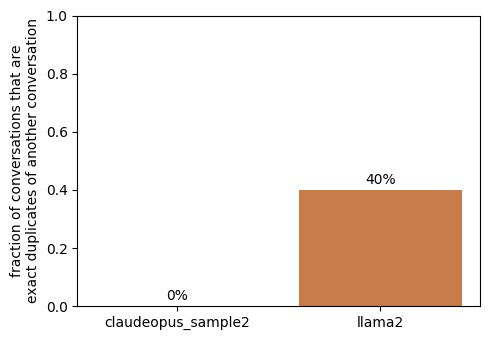

In [5]:
dup_flag = df.duplicated("text_sha", keep=False)
df["is_dup_group"] = dup_flag

dup_summary = pd.DataFrame({
    "conversations": df.groupby("dataset").size(),
    "unique_texts": df.groupby("dataset")["text_sha"].nunique(),
})
dup_summary["duplicate_rows"] = dup_summary["conversations"] - dup_summary["unique_texts"]
dup_summary["duplicate_rate"] = dup_summary["duplicate_rows"] / dup_summary["conversations"]
display(dup_summary)

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(dup_summary.index, dup_summary["duplicate_rate"], color=[PALETTE[d] for d in dup_summary.index])
ax.set_ylabel("fraction of conversations that are\nexact duplicates of another conversation")
ax.set_ylim(0, 1)
for i, v in enumerate(dup_summary["duplicate_rate"]):
    ax.text(i, v + 0.02, f"{v:.0%}", ha="center")
plt.tight_layout()
plt.show()

In [6]:
dup_by_attr = (
    df[df.dataset == "llama2"]
    .groupby(["attribute", "level"], observed=True)["text_sha"]
    .apply(lambda s: s.duplicated(keep="first").mean())
    .unstack("level")
)
print("llama2 duplicate rate by attribute × level:")
display(dup_by_attr)

example_group = df[df.dataset == "llama2"].groupby("text_sha").filter(lambda g: len(g) > 1).sort_values("text_sha")
biggest = example_group.groupby("text_sha").size().idxmax()
print("\nlargest exact-duplicate cluster in llama2:")
display(example_group[example_group.text_sha == biggest][["attribute", "level", "idx", "path"]])

llama2 duplicate rate by attribute × level:


level,low,medium,neutral,high
attribute,,,,
certainty_seeking,0.400000,NaN,0.4,0.4
gullibility,0.384615,0.4,NaN,0.4
rationality,0.400000,0.4,NaN,0.4
seriousness,0.400000,0.4,NaN,0.4



largest exact-duplicate cluster in llama2:


,attribute,level,idx,path
1064,seriousness,low,0,../datasets_llama2/seriousness/conversation_0_seriousness_low.txt
1100,seriousness,low,20,../datasets_llama2/seriousness/conversation_20_seriousness_low.txt
1097,seriousness,low,1,../datasets_llama2/seriousness/conversation_1_seriousness_low.txt
1067,seriousness,low,10,../datasets_llama2/seriousness/conversation_10_seriousness_low.txt
1130,seriousness,low,2,../datasets_llama2/seriousness/conversation_2_seriousness_low.txt


**Finding:** `datasets_llama2` contains a substantial fraction of exact-duplicate conversations (the same generated text saved under multiple `conversation_<idx>` filenames, including some large clusters), while `claudeopus_sample2` has none. The *effective* unique sample size of `llama2` is materially smaller than its file count suggests — anything counting rows from this directory (training set size, per-level n) should count `text_sha.nunique()`, not file count.

## 5 · Conversation length — turns

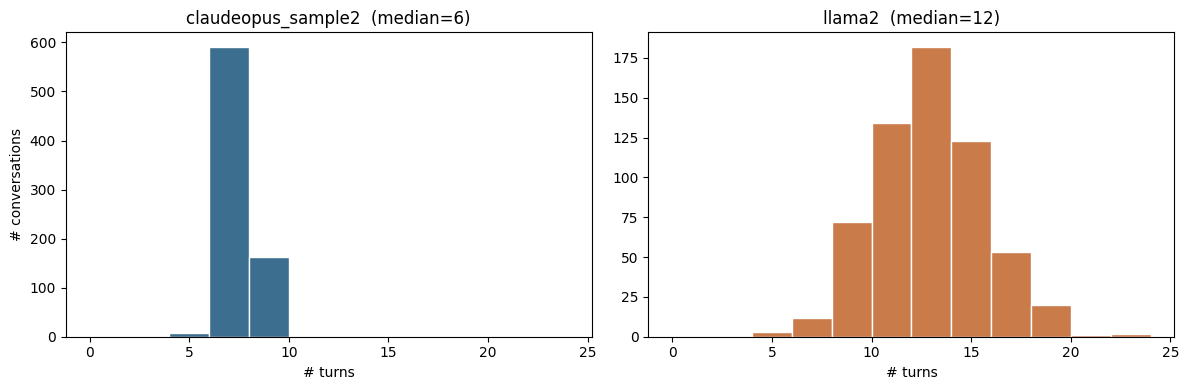

,mean,50%,min,max
dataset,,,,
claudeopus_sample2,6.424442,6.0,5.0,8.0
llama2,12.167774,12.0,4.0,22.0


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
bins = np.arange(0, df.num_turns.max() + 3, 2)
for ax, (ds_name, sub) in zip(axes, df.groupby("dataset")):
    ax.hist(sub.num_turns, bins=bins, color=PALETTE[ds_name], edgecolor="white")
    ax.set_title(f"{ds_name}  (median={sub.num_turns.median():.0f})")
    ax.set_xlabel("# turns")
axes[0].set_ylabel("# conversations")
plt.tight_layout()
plt.show()

df.groupby("dataset")["num_turns"].describe()[["mean", "50%", "min", "max"]]

## 6 · Message length — words per turn, by role

Split by `role` (HUMAN vs ASSISTANT) and by `dataset`.

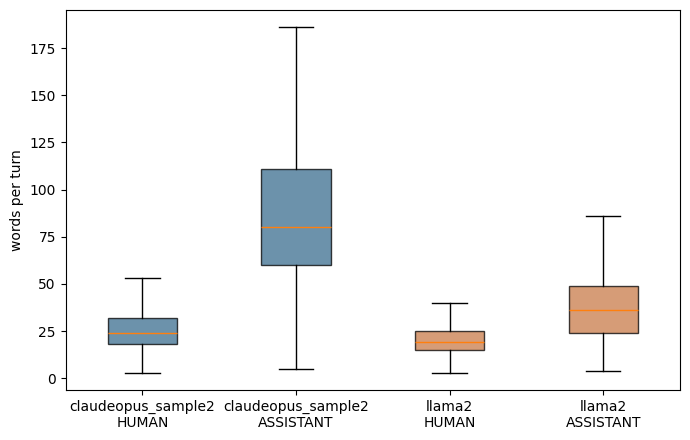

role,ASSISTANT,HUMAN
dataset,,
claudeopus_sample2,80.0,24.0
llama2,36.0,19.0


In [8]:
fig, ax = plt.subplots(figsize=(7, 4.5))
positions, labels, data, colors = [], [], [], []
pos = 0
for ds_name in DATASETS:
    for role in ["HUMAN", "ASSISTANT"]:
        vals = turns_df[(turns_df.dataset == ds_name) & (turns_df.role == role)]["words"]
        data.append(vals.values)
        labels.append(f"{ds_name}\n{role}")
        colors.append(PALETTE[ds_name])
        pos += 1
bp = ax.boxplot(data, showfliers=False, patch_artist=True)
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.75)
ax.set_xticks(range(1, len(labels) + 1))
ax.set_xticklabels(labels)
ax.set_ylabel("words per turn")
plt.tight_layout()
plt.show()

turns_df.groupby(["dataset", "role"])["words"].median().unstack("role")

`claudeopus_sample2` writes short HUMAN turns and long ASSISTANT turns (real-chat-like asymmetry); `llama2` HUMAN turns run longer and ASSISTANT turns shorter — the two generators have a noticeably different conversational register, independent of attribute or level.

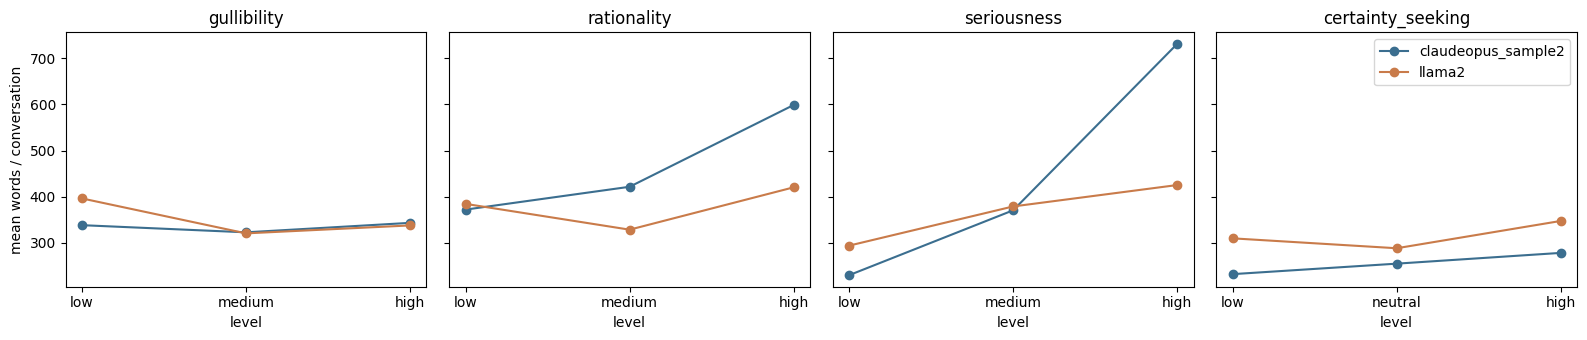

In [9]:
avg_len = (
    df.groupby(["dataset", "attribute", "level"], observed=True)[["human_words", "asst_words"]]
    .mean()
    .reset_index()
)
fig, axes = plt.subplots(1, len(ATTRS), figsize=(16, 3.5), sharey="row")
for ax, attr in zip(axes, ATTRS):
    sub = avg_len[avg_len.attribute == attr]
    for ds_name, g in sub.groupby("dataset"):
        g = g.set_index("level").reindex([l for l in LEVEL_ORDER if l in g.level.values])
        ax.plot(g.index.astype(str), g.human_words + g.asst_words, marker="o", label=ds_name, color=PALETTE[ds_name])
    ax.set_title(attr)
    ax.set_xlabel("level")
axes[0].set_ylabel("mean words / conversation")
axes[-1].legend()
plt.tight_layout()
plt.show()

Any level-to-level slope above is a property of *this generated batch*, not a validated attribute effect — with the sample sizes here (tens to ~120 per cell) and `claudeopus_sample2` still mid-run, it should be read as descriptive, not as evidence that (say) "high gullibility conversations run longer."

## 7 · Vocabulary

Type count, type-token ratio (a crude lexical-diversity proxy), and top words per dataset, using a small hand-rolled stopword list (no external download).

,dataset,total_tokens,types,ttr
0,claudeopus_sample2,286535,14740,0.051442
1,llama2,219921,6713,0.030525


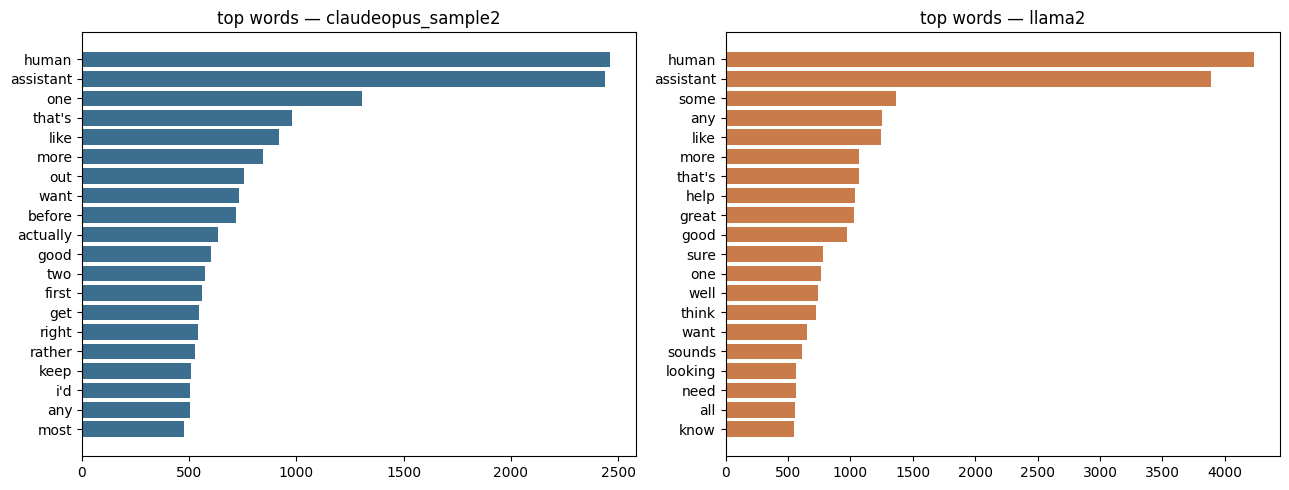

In [10]:
STOPWORDS = set("""a an the this that these those is are was were be been being have has had do does did
will would shall should may might can could must
i you he she it we they me him her us them my your his its our their mine yours hers ours theirs
and or but if then than so because as while of to in on for with at by from into about over under
not no nor very just really so too also
this that it its it's i'm you're he's she's they're we're don't can't won't isn't aren't
what who whom which when where why how
there here""".split())


def word_counts(texts):
    c = Counter()
    for t in texts:
        for w in re.findall(r"[a-zA-Z']+", t.lower()):
            if w not in STOPWORDS and len(w) > 2:
                c[w] += 1
    return c


raw_text = {}
for ds_name, ds_path in DATASETS.items():
    chunks = []
    for attr in ATTRS:
        d = ds_path / attr
        if d.exists():
            chunks += [f.read_text() for f in d.glob("*.txt")]
    raw_text[ds_name] = chunks

lex_stats = []
counters = {}
for ds_name, texts in raw_text.items():
    tokens = [w for t in texts for w in re.findall(r"[a-zA-Z']+", t.lower())]
    counters[ds_name] = word_counts(texts)
    lex_stats.append(dict(dataset=ds_name, total_tokens=len(tokens), types=len(set(tokens)),
                           ttr=len(set(tokens)) / len(tokens)))
display(pd.DataFrame(lex_stats))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (ds_name, c) in zip(axes, counters.items()):
    top = c.most_common(20)
    words, freqs = zip(*top[::-1])
    ax.barh(words, freqs, color=PALETTE[ds_name])
    ax.set_title(f"top words — {ds_name}")
plt.tight_layout()
plt.show()

## 8 · Style markers — bracketed stage directions

`llama2` occasionally narrates action in angle brackets (e.g. `<pauses>`, `<searches online>`) — a stage-direction habit that reads more like a screenplay than a chat transcript. Checking whether `claudeopus_sample2` does the same.

In [11]:
stage_summary = df.groupby("dataset")["stage_dirs"].agg(
    conversations_with_any=lambda s: (s > 0).mean(),
    total_occurrences="sum",
)
display(stage_summary)

examples = []
for ds_name, ds_path in DATASETS.items():
    for attr in ATTRS:
        d = ds_path / attr
        if not d.exists():
            continue
        for f in d.glob("*.txt"):
            m = re.search(r"<[^<>]{1,40}>", f.read_text())
            if m:
                examples.append((ds_name, f.name, m.group()))
                break
        if len(examples) >= 6:
            break
pd.DataFrame(examples, columns=["dataset", "file", "example_tag"])

,conversations_with_any,total_occurrences
dataset,,
claudeopus_sample2,0.000000,0
llama2,0.023256,43


,dataset,file,example_tag
0,llama2,conversation_0_gullibility_low.txt,<pauses>
1,llama2,conversation_30_rationality_medium.txt,<laughs>
2,llama2,conversation_34_seriousness_low.txt,<laughs>
3,llama2,conversation_38_certainty_seeking_neutral.txt,<smirk>


## 9 · Attribute-label leakage

The generation prompt (see the `claudeopus_sample2` JSON sidecars) explicitly forbids the user turn from naming the trait. `claudeopus_sample2` records this itself as `leak_stems_found`; for both datasets we can also grep the HUMAN turns directly for the four attribute-name stems as a rough cross-check.

In [12]:
LEAK_STEMS = {
    "gullibility": ["gullib", "credulous", "naive", "naïve"],
    "rationality": ["rational", "irrational", "logical"],
    "seriousness": ["serious", "somber", "solemn"],
    "certainty_seeking": ["certain", "certainty", "reassur"],
}

leak_rows = []
for ds_name, ds_path in DATASETS.items():
    for attr, stems in LEAK_STEMS.items():
        d = ds_path / attr
        if not d.exists():
            continue
        for f in d.glob("*.txt"):
            human_text = " ".join(c for r, c in parse_turns(f.read_text()) if r == "HUMAN").lower()
            hits = [s for s in stems if s in human_text]
            if hits:
                leak_rows.append(dict(dataset=ds_name, attribute=attr, file=f.name, stems=hits))

leak_df = pd.DataFrame(leak_rows)
print(f"HUMAN-turn stem hits: {len(leak_df)} conversations")
if len(leak_df):
    display(leak_df.groupby(["dataset", "attribute"]).size().rename("flagged_conversations"))

print(f"\nclaudeopus_sample2 self-reported leak_stems_found (json sidecar): "
      f"{int(df.loc[df.dataset=='claudeopus_sample2', 'leak_stems'].sum())} total stem hits across "
      f"{(df.loc[df.dataset=='claudeopus_sample2', 'leak_stems'] > 0).sum()} conversations")

HUMAN-turn stem hits: 36 conversations


dataset             attribute        
claudeopus_sample2  certainty_seeking     2
                    rationality           3
                    seriousness           6
llama2              seriousness          25
Name: flagged_conversations, dtype: int64


claudeopus_sample2 self-reported leak_stems_found (json sidecar): 34 total stem hits across 34 conversations


A handful of stem hits are expected false positives (e.g. "certain" used as an ordinary determiner, not a claim about certainty) — this is a coarse screen, not a precise leak count.

## 10 · Topic coverage (`claudeopus_sample2` only)

`llama2` has no topic metadata, so this section only covers `claudeopus_sample2`.

654 unique topics across 761 conversations (86% of conversations have a distinct topic)


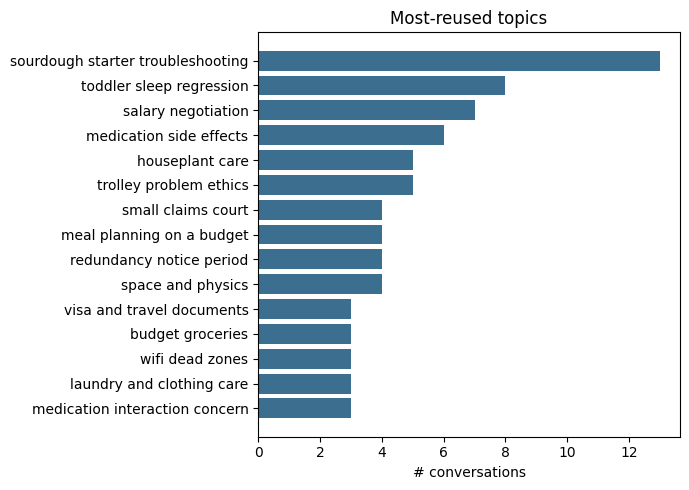

topics that appear at >1 level: 38 / 654


In [13]:
cop = df[df.dataset == "claudeopus_sample2"]
print(f"{cop.topic.nunique()} unique topics across {len(cop)} conversations "
      f"({cop.topic.nunique() / len(cop):.0%} of conversations have a distinct topic)")

top_topics = cop.topic.value_counts().head(15)
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(top_topics.index[::-1], top_topics.values[::-1], color=PALETTE["claudeopus_sample2"])
ax.set_xlabel("# conversations")
ax.set_title("Most-reused topics")
plt.tight_layout()
plt.show()

reused = cop.groupby("topic")["level"].nunique()
print(f"topics that appear at >1 level: {(reused > 1).sum()} / {cop.topic.nunique()}")

## 11 · Generation-pipeline quality (`claudeopus_sample2/run.log`)

`run.log` records the batch job's progress and every rejected/dropped attempt — this is a direct look at how noisy the generation process is, independent of anything about the attribute itself.

In [14]:
log_path = DATASETS["claudeopus_sample2"] / "run.log"
log_lines = log_path.read_text().splitlines()
header = [l for l in log_lines if ":" in l and not l.strip().startswith("[")][:6]
print("\n".join(header))

drop_re = re.compile(r"^\s*\[(\w+)\] (dropped|rejected|call)")
events = Counter()
for l in log_lines:
    m = re.match(r"^\s*\[(\w+)\] (dropped|call \d+ attempt \d+ rejected)", l)
    if m:
        attr = m.group(1)
        kind = "dropped" if l.strip().split("] ", 1)[1].startswith("dropped") else "rejected"
        events[(attr, kind)] += 1

ev_df = pd.Series(events).unstack(fill_value=0)
display(ev_df)
print(f"\ntotal dropped/rejected events logged: {sum(events.values())}")
print(f"conversations on disk: {len(cop)} / 1200 target ({len(cop)/1200:.0%} complete)")

Model:       claude-opus-5
Attributes:  gullibility, rationality, seriousness, certainty_seeking
Per level:   100   (target 1200 conversations)
Per call:    2 per level, breadth-first across attributes
Output:      datasets_claudeopus_sample2/
Resuming: 48 conversation(s) already on disk are being kept.


,dropped,rejected
certainty_seeking,2,1
gullibility,1,0
seriousness,1,1



total dropped/rejected events logged: 6
conversations on disk: 761 / 1200 target (63% complete)


## 12 · Missing-data check

In [15]:
print(f"unparseable / malformed filenames: {len(bad_filenames)}")
print(f"claudeopus_sample2 .txt files missing a .json sidecar: {(~df.loc[df.dataset=='claudeopus_sample2', 'has_json']).sum()}")
print(f"conversations with zero turns: {(df.num_turns == 0).sum()}")
print(f"conversations with zero HUMAN or zero ASSISTANT turns: {((df.n_human == 0) | (df.n_assistant == 0)).sum()}")

unparseable / malformed filenames: 0
claudeopus_sample2 .txt files missing a .json sidecar: 0
conversations with zero turns: 0
conversations with zero HUMAN or zero ASSISTANT turns: 0


## 13 · Summary

**Volume**
- `claudeopus_sample2`: 761 conversations on disk (63%) toward a stated 1200-conversation target — the
  batch job is mid-run (`run.log` shows a resume), roughly balanced across levels within each attribute.
- `llama2`: 602 conversation files, closer to a flat ~50/level design, but…

**Data quality — the main finding**
- `llama2` has **~40% exact-duplicate conversations** (240/602; same text saved under different
  `conversation_<idx>` filenames, including one cluster of 5 identical files), and the rate is close to
  40% in every attribute × level cell. Its *effective* unique sample is ~362 conversations, not 602.
  `claudeopus_sample2` has zero exact duplicates.
- `llama2` also has a small number of **role-alternation violations** (two consecutive `HUMAN` turns),
  which `claudeopus_sample2` does not.
- A coarse stem-match screen finds a handful of HUMAN turns in both datasets that mention attribute-adjacent
  words despite the generation prompt forbidding it; `claudeopus_sample2`'s own `leak_stems_found` field
  agrees this is rare.

**Style**
- The two generators write structurally different conversations: `claudeopus_sample2` has short HUMAN /
  long ASSISTANT turns and no stage directions; `llama2` has longer HUMAN / shorter ASSISTANT turns and
  occasionally narrates action in `<angle brackets>`, reading more like a script than a chat log.
- `claudeopus_sample2` conversations run shorter in turn count with more words per turn; `llama2` runs to
  more, shorter turns.

**Caveats**
- All of the above describes the *generated text*, not the attribute manipulation's effectiveness — no
  claim here about whether `low`/`medium`/`high` actually encodes the intended behavioural difference.
- `claudeopus_sample2` counts are a snapshot of an unfinished run; re-run this notebook once generation
  completes (or the log shows no further "Resuming" line) before treating per-level counts as final.
- Given the `llama2` duplication found in §4, any downstream use of `datasets_llama2` (training/probing)
  should deduplicate by `text_sha` first, or per-level effective sample sizes will be inflated.